# Projeto de Machine Learning: Previsão de Preços de Moradia em São Paulo

Este notebook apresenta, de forma didática, a construção de um modelo de regressão para estimar o valor total mensal de imóveis na cidade de São Paulo.

A proposta traz explicações claras sobre o que cada etapa faz, por que ela é importante e como interpretar os resultados.

## Objetivos do projeto
- Entender a estrutura e a qualidade dos dados.
- Explorar relações entre características dos imóveis e preço.
- Preparar os dados com um pipeline robusto e reproduzível.
- Treinar e comparar diferentes modelos de regressão.
- Ajustar hiperparâmetros para melhorar desempenho.
- Gerar um modelo final pronto para prever novos imóveis.

> Variável alvo escolhida: total (valor total mensal do imóvel).

## Guia rápido de execução

Siga esta sequência:

1. Execute as células na ordem, de cima para baixo.
2. Em cada etapa, leia primeiro o texto explicativo e depois o código.
3. Observe a saída (tabelas, métricas e gráficos) para entender o resultado.
4. Ao final, veja os exemplos de previsão para cenários reais.

## Glossário essencial

- Dataset: conjunto de dados usado no estudo.
- Variável alvo: valor que queremos prever (neste projeto, total).
- Feature (variável de entrada): informação usada para prever o alvo, como área, bairro e tipo do imóvel.
- Treino: parte dos dados usada para ensinar o modelo.
- Teste: parte dos dados usada para verificar se o modelo funciona bem em dados novos.
- Pipeline: sequência organizada de etapas de preparação e modelagem.
- One-hot encoding: técnica para transformar texto (ex.: bairro) em formato numérico.
- Validação cruzada: método para avaliar o modelo em diferentes divisões dos dados.
- MAE, RMSE e R²: métricas usadas para medir qualidade de previsão.
- Hiperparâmetros: configurações do algoritmo que podem ser ajustadas para melhorar o desempenho.
- Inferência: uso do modelo treinado para prever novos casos.

In [3]:
# Imports principais
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_validate, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

# Compatibilidade entre versões do scikit-learn
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [22]:
# Carregamento do dataset
DATA_PATH = "data/data.csv"
df = pd.read_csv(DATA_PATH)

print(f"Formato do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
display(df.head())

Formato do dataset: 11657 linhas x 8 colunas


,address,district,area,bedrooms,garage,type,rent,total
0,Rua Herval,Belenzinho,21,1,0,Studio e kitnet,2400,2939
1,Avenida São Miguel,Vila Marieta,15,1,1,Studio e kitnet,1030,1345
2,Rua Oscar Freire,Pinheiros,18,1,0,Apartamento,4000,4661
3,Rua Júlio Sayago,Vila Ré,56,2,2,Casa em condomínio,1750,1954
4,Rua Barata Ribeiro,Bela Vista,19,1,0,Studio e kitnet,4000,4654


In [23]:
# Inspeção inicial e qualidade dos dados
print("Tipos de dados:")
display(df.dtypes.to_frame("dtype"))

print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("missing"))

print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

print("\nResumo estatístico:")
display(df.describe(include="all").T)

Tipos de dados:


,dtype
address,str
district,str
area,int64
bedrooms,int64
garage,int64
type,str
rent,int64
total,int64



Valores ausentes por coluna:


,missing
address,0
district,0
area,0
bedrooms,0
garage,0
type,0
rent,0
total,0



Linhas duplicadas: 0

Resumo estatístico:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
address,11657,5348,Rua da Consolação,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,11657,1199,Bela Vista,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,11657.0,NaN,NaN,NaN,84.655658,74.020536,0.0,40.0,60.0,96.0,580.0
bedrooms,11657.0,NaN,NaN,NaN,1.966286,0.931313,0.0,1.0,2.0,3.0,6.0
garage,11657.0,NaN,NaN,NaN,1.060393,1.132349,0.0,0.0,1.0,2.0,6.0
type,11657,4,Apartamento,7194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rent,11657.0,NaN,NaN,NaN,3250.814789,2650.711557,500.0,1590.0,2415.0,3800.0,25000.0
total,11657.0,NaN,NaN,NaN,4080.030625,3352.480274,509.0,1996.0,3057.0,4774.0,28700.0


In [24]:
# Limpeza e padronização
df_model = df.copy()

# Padroniza texto para reduzir cardinalidade por variações de escrita
for col in ["district", "type"]:
    df_model[col] = (
        df_model[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

# Conversão segura de colunas numéricas
numeric_cols_all = ["area", "bedrooms", "garage", "rent", "total"]
for col in numeric_cols_all:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Remove duplicidades e valores inválidos básicos
df_model = df_model.drop_duplicates()
df_model = df_model[(df_model["area"] > 0) & (df_model["total"] > 0)]

display(df_model.head())
print(f"Dataset após limpeza: {df_model.shape[0]} linhas x {df_model.shape[1]} colunas")

,address,district,area,bedrooms,garage,type,rent,total
0,Rua Herval,belenzinho,21,1,0,studio e kitnet,2400,2939
1,Avenida São Miguel,vila marieta,15,1,1,studio e kitnet,1030,1345
2,Rua Oscar Freire,pinheiros,18,1,0,apartamento,4000,4661
3,Rua Júlio Sayago,vila ré,56,2,2,casa em condomínio,1750,1954
4,Rua Barata Ribeiro,bela vista,19,1,0,studio e kitnet,4000,4654


Dataset após limpeza: 11655 linhas x 8 colunas


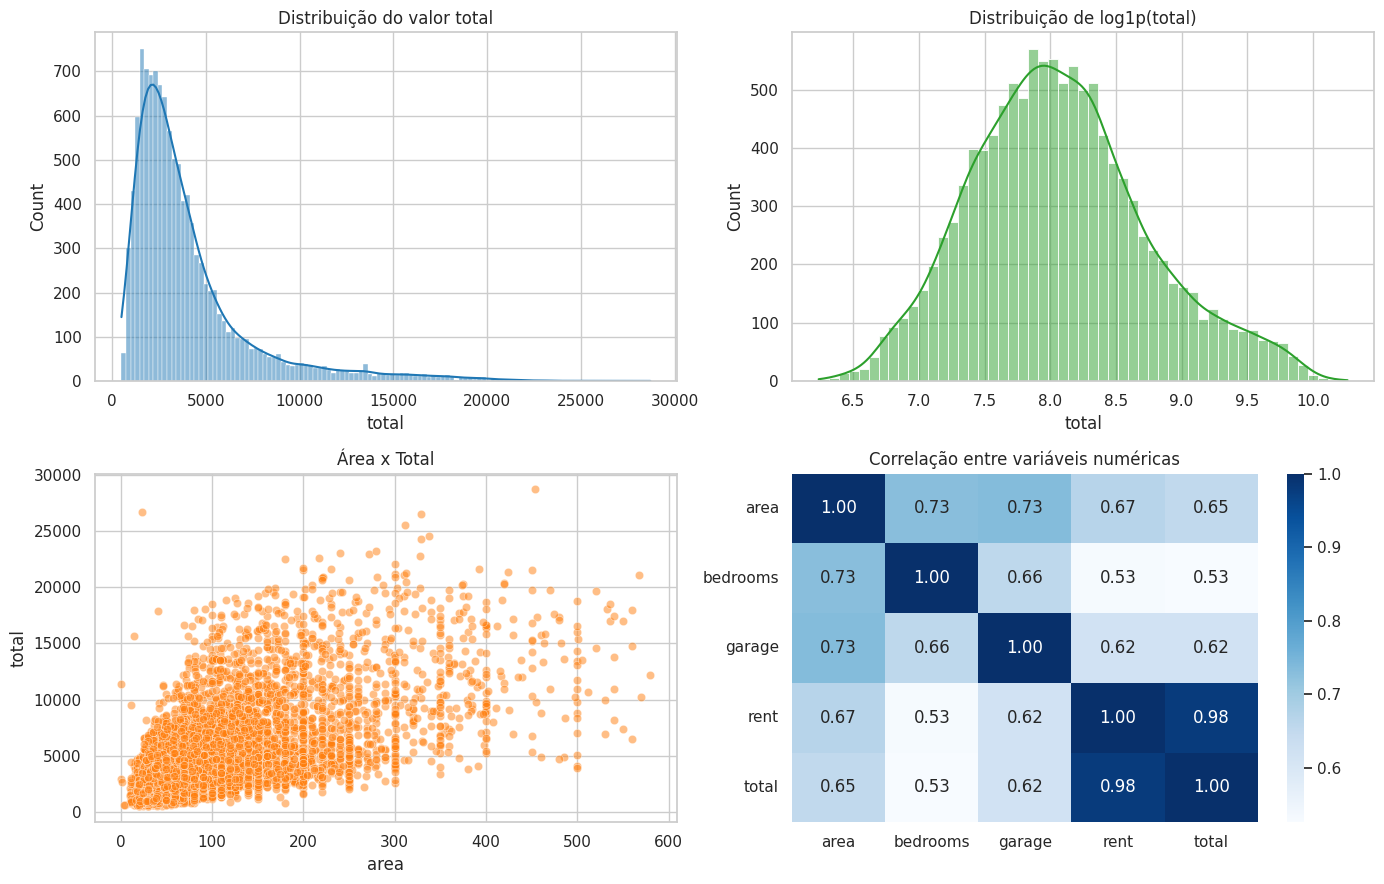

In [25]:
# Análise exploratória: distribuição de variáveis numéricas
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df_model["total"], kde=True, ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Distribuição do valor total")

sns.histplot(np.log1p(df_model["total"]), kde=True, ax=axes[0, 1], color="#2ca02c")
axes[0, 1].set_title("Distribuição de log1p(total)")

sns.scatterplot(data=df_model, x="area", y="total", alpha=0.5, ax=axes[1, 0], color="#ff7f0e")
axes[1, 0].set_title("Área x Total")

corr = df_model[["area", "bedrooms", "garage", "rent", "total"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=axes[1, 1])
axes[1, 1].set_title("Correlação entre variáveis numéricas")

plt.tight_layout()
plt.show()

Top 15 bairros por mediana de valor total:


,count,median,mean
district,,,
cidade jardim,1,20380.0,20380.000000
alphaville residencial plus,1,20270.0,20270.000000
alphaville residencial dois,1,17410.0,17410.000000
jardim cordeiro,1,16670.0,16670.000000
jardim vitoria regia (zona oeste),1,16480.0,16480.000000
jardim tango,1,15640.0,15640.000000
residencial cinco (alphaville),1,15380.0,15380.000000
alphaville residencial um,2,15030.0,15030.000000
centro empresarial tamboré,3,14760.0,14430.000000


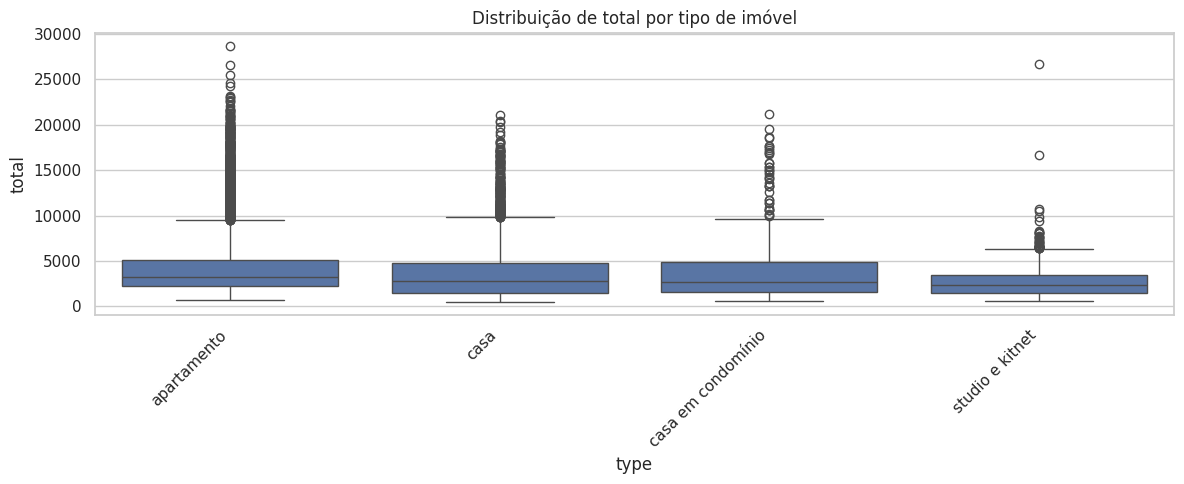

In [26]:
# Análise exploratória: bairros e tipos de imóvel
top_districts = (
    df_model.groupby("district")["total"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)

print("Top 15 bairros por mediana de valor total:")
display(top_districts.head(15))

plt.figure(figsize=(12, 5))
order_type = df_model.groupby("type")["total"].median().sort_values(ascending=False).index
sns.boxplot(data=df_model, x="type", y="total", order=order_type)
plt.xticks(rotation=45, ha="right")
plt.title("Distribuição de total por tipo de imóvel")
plt.tight_layout()
plt.show()

In [27]:
# Definição de features e alvo
TARGET = "total"
feature_columns = ["district", "type", "area", "bedrooms", "garage"]

X = df_model[feature_columns].copy()
y = df_model[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 9324 amostras
Teste: 2331 amostras


In [28]:
# Pipeline de pré-processamento
numeric_features = ["area", "bedrooms", "garage"]
categorical_features = ["district", "type"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", ohe),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print("Pré-processador definido.")

Pré-processador definido.


In [29]:
# Modelos candidatos e validação cruzada
base_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(
        n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_rows = []
for name, model in base_models.items():
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    reg = TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1,
    )

    scores = cross_validate(
        reg,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    cv_rows.append(
        {
            "Model": name,
            "CV_MAE": -scores["test_MAE"].mean(),
            "CV_RMSE": -scores["test_RMSE"].mean(),
            "CV_R2": scores["test_R2"].mean(),
        }
    )

cv_results = pd.DataFrame(cv_rows).sort_values("CV_RMSE").reset_index(drop=True)
print("Desempenho médio em validação cruzada (treino):")
display(cv_results)

Desempenho médio em validação cruzada (treino):


,Model,CV_MAE,CV_RMSE,CV_R2
0,RandomForest,1080.879904,1815.437018,0.704502
1,GradientBoosting,1125.995541,1868.352087,0.687692
2,Ridge,1112.076016,2035.031152,0.629209
3,LinearRegression,1127.139471,2056.593928,0.621452
4,Lasso,1248.524071,2254.767283,0.543723


## Como interpretar os testes de modelos

Nesta etapa, comparo modelos usando métricas numéricas. A leitura correta das métricas é:

- CV_MAE (erro absoluto médio na validação cruzada): média do erro em reais. Quanto menor, melhor.
- CV_RMSE (raiz do erro quadrático médio na validação cruzada): também mede erro em reais, mas penaliza mais os erros grandes. Quanto menor, melhor.
- CV_R2 (coeficiente de determinação na validação cruzada): indica o quanto o modelo explica da variação dos preços. Quanto mais próximo de 1, melhor.

Por que usar validação cruzada:
- Evita avaliar o modelo em apenas uma divisão específica dos dados.
- Gera uma estimativa mais estável do desempenho.

Após essa visão inicial, analiso as métricas no conjunto de teste para escolher o melhor modelo final.

In [44]:
# Treino dos modelos base e avaliação no conjunto de teste
fitted_models = {}
base_test_rows = []

for name, model in base_models.items():
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    reg = TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1,
    )

    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)

    fitted_models[name] = reg
    base_test_rows.append(
        {
            "Model": name,
            "Test_MAE": mean_absolute_error(y_test, y_pred),
            "Test_RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
            "Test_R2": r2_score(y_test, y_pred),
        }
    )

base_test_results = pd.DataFrame(base_test_rows).sort_values("Test_RMSE").reset_index(drop=True)
print("Desempenho no conjunto de teste (modelos base):")
display(base_test_results)

Desempenho no conjunto de teste (modelos base):


,Model,Test_MAE,Test_RMSE,Test_R2,Chance_Acerto_10pct,Chance_Acerto_20pct
0,RandomForest,1089.786527,1796.242736,0.716642,26.855427,48.991849
1,GradientBoosting,1127.713439,1845.688947,0.700827,23.208923,44.787645
2,Ridge,1057.137766,1891.931385,0.685648,26.469326,52.166452
3,LinearRegression,1067.591101,1928.631815,0.673334,26.426426,52.037752
4,Lasso,1213.782763,2086.950955,0.617501,22.737023,42.556843


In [31]:
# Ajuste de hiperparâmetros (RandomForest)
rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        ),
    ]
)

rf_reg = TransformedTargetRegressor(
    regressor=rf_pipe,
    func=np.log1p,
    inverse_func=np.expm1,
)

rf_param_dist = {
    "regressor__model__n_estimators": [200, 300, 400],
    "regressor__model__max_depth": [None, 10, 20],
    "regressor__model__min_samples_split": [2, 5],
    "regressor__model__min_samples_leaf": [1, 2],
    "regressor__model__max_features": ["sqrt", "log2", None],
}

rf_search = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=rf_param_dist,
    n_iter=8,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

rf_search.fit(X_train, y_train)
print("Melhor RF (CV RMSE):", -rf_search.best_score_)
print("Melhores hiperparâmetros RF:", rf_search.best_params_)

Melhor RF (CV RMSE): 1764.6784428789522
Melhores hiperparâmetros RF: {'regressor__model__n_estimators': 300, 'regressor__model__min_samples_split': 5, 'regressor__model__min_samples_leaf': 1, 'regressor__model__max_features': 'sqrt', 'regressor__model__max_depth': None}


In [32]:
# Ajuste de hiperparâmetros (GradientBoosting)
gb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
    ]
)

gb_reg = TransformedTargetRegressor(
    regressor=gb_pipe,
    func=np.log1p,
    inverse_func=np.expm1,
)

gb_param_dist = {
    "regressor__model__n_estimators": [200, 300, 500],
    "regressor__model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "regressor__model__max_depth": [2, 3, 4],
    "regressor__model__min_samples_split": [2, 5],
    "regressor__model__min_samples_leaf": [1, 2],
    "regressor__model__subsample": [0.7, 0.85, 1.0],
}

gb_search = RandomizedSearchCV(
    estimator=gb_reg,
    param_distributions=gb_param_dist,
    n_iter=8,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

gb_search.fit(X_train, y_train)
print("Melhor GB (CV RMSE):", -gb_search.best_score_)
print("Melhores hiperparâmetros GB:", gb_search.best_params_)

Melhor GB (CV RMSE): 1749.5616887604638
Melhores hiperparâmetros GB: {'regressor__model__subsample': 0.7, 'regressor__model__n_estimators': 200, 'regressor__model__min_samples_split': 2, 'regressor__model__min_samples_leaf': 2, 'regressor__model__max_depth': 4, 'regressor__model__learning_rate': 0.1}


In [45]:
# Comparação final entre modelos base e modelos tunados
candidate_models = dict(fitted_models)
candidate_models["RandomForest_Tuned"] = rf_search.best_estimator_
candidate_models["GradientBoosting_Tuned"] = gb_search.best_estimator_

final_rows = []
for name, model in candidate_models.items():
    preds = model.predict(X_test)
    final_rows.append(
        {
            "Model": name,
            "Test_MAE": mean_absolute_error(y_test, preds),
            "Test_RMSE": float(np.sqrt(mean_squared_error(y_test, preds))),
            "Test_R2": r2_score(y_test, preds),
        }
    )

final_results = pd.DataFrame(final_rows).sort_values("Test_RMSE").reset_index(drop=True)
display(final_results)

best_model_name = final_results.iloc[0]["Model"]
best_model = candidate_models[best_model_name]
print(f"Melhor modelo no teste: {best_model_name}")

,Model,Test_MAE,Test_RMSE,Test_R2,Chance_Acerto_10pct,Chance_Acerto_20pct
0,RandomForest_Tuned,589.788097,1046.768122,0.903771,47.661948,77.262977
1,GradientBoosting_Tuned,1043.425697,1700.294600,0.746105,25.268125,49.377949
2,RandomForest,1089.786527,1796.242736,0.716642,26.855427,48.991849
3,GradientBoosting,1127.713439,1845.688947,0.700827,23.208923,44.787645
4,Ridge,1057.137766,1891.931385,0.685648,26.469326,52.166452
5,LinearRegression,1067.591101,1928.631815,0.673334,26.426426,52.037752
6,Lasso,1213.782763,2086.950955,0.617501,22.737023,42.556843


Melhor modelo no teste: RandomForest_Tuned


### Leitura dos resultados do conjunto de teste

No conjunto de teste, as colunas comparadas são:

- Test_MAE: erro médio absoluto em reais.
- Test_RMSE: erro que penaliza mais previsões muito distantes do valor real.
- Test_R2: capacidade do modelo de explicar a variação dos preços.

Regra prática para escolha:
- Menor Test_RMSE e menor Test_MAE indicam previsões mais precisas.
- Maior Test_R2 indica melhor explicação da variação dos dados.

A célula abaixo gera um resumo automático indicando o melhor modelo e o ganho em relação ao segundo colocado.

In [46]:
# Resumo automático dos resultados de teste
melhor = final_results.iloc[0]
segundo = final_results.iloc[1]

ganho_rmse = ((segundo["Test_RMSE"] - melhor["Test_RMSE"]) / segundo["Test_RMSE"]) * 100
ganho_mae = ((segundo["Test_MAE"] - melhor["Test_MAE"]) / segundo["Test_MAE"]) * 100

resumo_modelo = pd.DataFrame(
    {
        "Indicador": [
            "Melhor modelo (teste)",
            "RMSE do melhor modelo",
            "MAE do melhor modelo",
            "R² do melhor modelo",
            "Ganho de RMSE vs 2º modelo",
            "Ganho de MAE vs 2º modelo",
        ],
        "Valor": [
            melhor["Model"],
            f"{melhor['Test_RMSE']:.2f}",
            f"{melhor['Test_MAE']:.2f}",
            f"{melhor['Test_R2']:.4f}",
            f"{ganho_rmse:.2f}%",
            f"{ganho_mae:.2f}%",
        ],
    }
)

print("Interpretação objetiva dos testes:")
display(resumo_modelo)

print(
    f"Conclusão: o melhor desempenho foi do modelo '{melhor['Model']}', "
    f"com Test_RMSE = {melhor['Test_RMSE']:.2f}, "
    f"Test_MAE = {melhor['Test_MAE']:.2f} e Test_R2 = {melhor['Test_R2']:.4f}."
)

Interpretação objetiva dos testes:


Interpretação objetiva dos testes:


,Indicador,Valor
0,Melhor modelo (teste),RandomForest_Tuned
1,RMSE do melhor modelo,1046.77
2,MAE do melhor modelo,589.79
3,R² do melhor modelo,0.9038
4,Chance de acerto (erro <= 10%),47.66%
5,Chance de acerto (erro <= 20%),77.26%
6,Ganho de RMSE vs 2º modelo,38.44%
7,Ganho de MAE vs 2º modelo,43.48%
8,Ganho de chance <= 10% vs 2º modelo,+22.39 p.p.
9,Ganho de chance <= 20% vs 2º modelo,+27.89 p.p.


Conclusão: o melhor desempenho foi do modelo 'RandomForest_Tuned', com Test_RMSE = 1046.77, Test_MAE = 589.79 e Test_R2 = 0.9038. Chance empírica de acerto: 47.66% (erro <= 10%) e 77.26% (erro <= 20%).


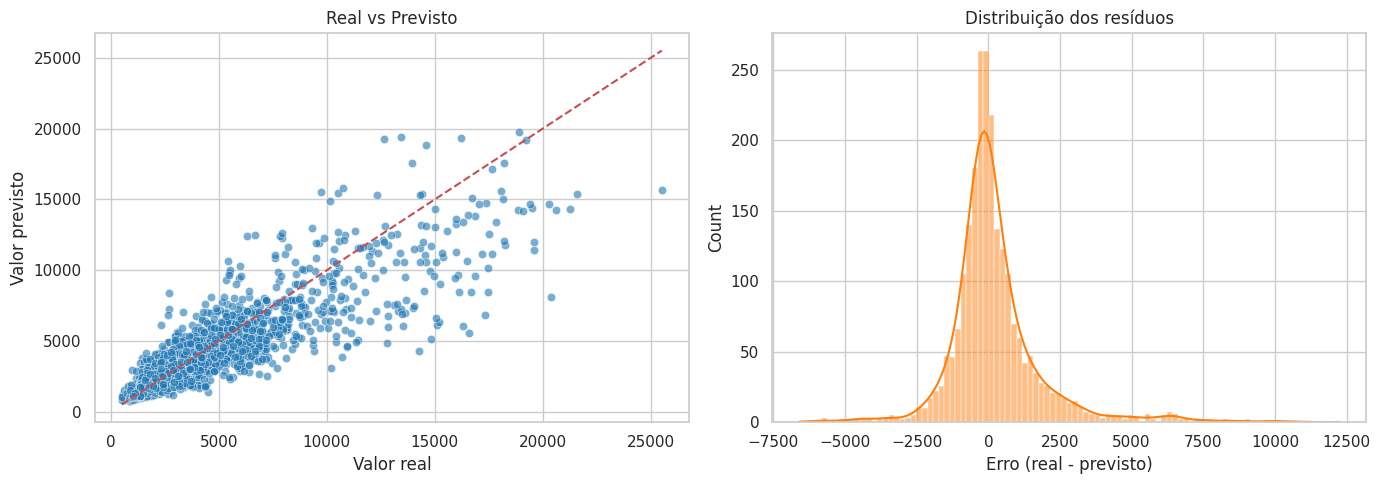

In [34]:
# Diagnóstico visual do melhor modelo no conjunto de teste
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.6, ax=axes[0], color="#1f77b4")
min_v = min(y_test.min(), y_pred_best.min())
max_v = max(y_test.max(), y_pred_best.max())
axes[0].plot([min_v, max_v], [min_v, max_v], "r--")
axes[0].set_title("Real vs Previsto")
axes[0].set_xlabel("Valor real")
axes[0].set_ylabel("Valor previsto")

residuals = y_test - y_pred_best
sns.histplot(residuals, kde=True, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Distribuição dos resíduos")
axes[1].set_xlabel("Erro (real - previsto)")

plt.tight_layout()
plt.show()

In [35]:
# Interpretação básica do modelo (importância ou coeficientes)
inner_pipe = best_model.regressor_
inner_model = inner_pipe.named_steps["model"]
feature_names = inner_pipe.named_steps["preprocessor"].get_feature_names_out()

if hasattr(inner_model, "feature_importances_"):
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": inner_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    print("Top 15 features mais importantes:")
    display(importance_df.head(15))

elif hasattr(inner_model, "coef_"):
    coef_df = pd.DataFrame(
        {
            "feature": feature_names,
            "coef": inner_model.coef_.ravel(),
            "abs_coef": np.abs(inner_model.coef_.ravel()),
        }
    ).sort_values("abs_coef", ascending=False)

    print("Top 15 coeficientes (magnitude):")
    display(coef_df[["feature", "coef"]].head(15))

else:
    print("Modelo final não expõe importância/coeficientes diretamente.")

Top 15 features mais importantes:


,feature,importance
0,num__area,0.234169
2,num__garage,0.207053
1,num__bedrooms,0.130999
1100,cat__type_apartamento,0.032863
1101,cat__type_casa,0.029176
373,cat__district_jardim paulista,0.021428
71,cat__district_cerqueira césar,0.016732
1103,cat__type_studio e kitnet,0.012784
611,cat__district_pinheiros,0.011768
912,cat__district_vila mariana,0.008268


In [36]:
# Treino final com todo o dataset e salvamento do artefato
best_model.fit(X, y)

artifact = {
    "model": best_model,
    "features": feature_columns,
    "target": TARGET,
    "random_state": RANDOM_STATE,
}

MODEL_PATH = "modelo_sp_prices.pkl"
joblib.dump(artifact, MODEL_PATH)
print(f"Modelo salvo em: {MODEL_PATH}")

Modelo salvo em: modelo_sp_prices.pkl


In [7]:
# Volume de treinos executados no pipeline

def obter_num_splits(cv_obj, default):
    if hasattr(cv_obj, "get_n_splits"):
        try:
            return int(cv_obj.get_n_splits())
        except Exception:
            return default
    try:
        return int(cv_obj)
    except Exception:
        return default

n_modelos_base = len(base_models) if "base_models" in globals() else 5
n_folds_cv = obter_num_splits(cv, default=5) if "cv" in globals() else 5

# 1) Validação cruzada dos modelos base
n_treinos_cv = n_modelos_base * n_folds_cv

# 2) Treino dos modelos base no conjunto de treino para avaliação em teste
n_treinos_base_teste = n_modelos_base

# 3) Busca RandomizedSearchCV do RandomForest (inclui refit final)
if "rf_search" in globals():
    rf_n_iter = int(rf_search.n_iter)
    rf_cv = obter_num_splits(rf_search.cv, default=3)
    rf_refit = 1 if rf_search.refit else 0
else:
    rf_n_iter, rf_cv, rf_refit = 8, 3, 1
n_treinos_rf = rf_n_iter * rf_cv + rf_refit

# 4) Busca RandomizedSearchCV do GradientBoosting (inclui refit final)
if "gb_search" in globals():
    gb_n_iter = int(gb_search.n_iter)
    gb_cv = obter_num_splits(gb_search.cv, default=3)
    gb_refit = 1 if gb_search.refit else 0
else:
    gb_n_iter, gb_cv, gb_refit = 8, 3, 1
n_treinos_gb = gb_n_iter * gb_cv + gb_refit

# 5) Treino final com o dataset completo
n_treino_final = 1

volume_treinos = pd.DataFrame(
    [
        ("CV modelos base", n_treinos_cv),
        ("Treino base para teste", n_treinos_base_teste),
        ("RandomSearch RF (+ refit)", n_treinos_rf),
        ("RandomSearch GB (+ refit)", n_treinos_gb),
        ("Treino final (X, y)", n_treino_final),
    ],
    columns=["Etapa", "Treinos"],
)

volume_treinos.loc[len(volume_treinos)] = ["TOTAL", volume_treinos["Treinos"].sum()]
display(volume_treinos)
print(f"Volume total de treinos: {int(volume_treinos.iloc[-1]['Treinos'])}")

,Etapa,Treinos
0,CV modelos base,25
1,Treino base para teste,5
2,RandomSearch RF (+ refit),25
3,RandomSearch GB (+ refit),25
4,"Treino final (X, y)",1
5,TOTAL,81


Volume total de treinos: 81


## Como carregar o artefato salvo (.pkl)

A carga do arquivo modelo_sp_prices.pkl permite fazer previsões sem retreinar o modelo.

Importante: isso só funciona se a célula de treino final e salvamento já tiver sido executada ao menos uma vez, pois ela é quem gera o arquivo .pkl.

In [4]:
from pathlib import Path

def carregar_modelo_salvo(model_path="modelo_sp_prices.pkl"):
    path = Path(model_path)
    if not path.exists():
        raise FileNotFoundError(
            f"Arquivo '{model_path}' não encontrado. "
            "Execute a célula de treino final e salvamento ao menos uma vez para gerar o .pkl."
        )

    artifact_carregado = joblib.load(path)
    return artifact_carregado["model"], artifact_carregado

modelo_carregado, artifact_carregado = carregar_modelo_salvo("modelo_sp_prices.pkl")
print("Modelo carregado do artefato com sucesso.")
print("Features esperadas:", artifact_carregado["features"])

Modelo carregado do artefato com sucesso.
Features esperadas: ['district', 'type', 'area', 'bedrooms', 'garage']


In [5]:
# Função utilitária para predição em novos dados
def prever_valor_total(district, tipo, area, bedrooms, garage, modelo=None):
    if modelo is None:
        if "best_model" in globals():
            modelo = best_model
        elif "modelo_carregado" in globals():
            modelo = modelo_carregado
        else:
            raise NameError(
                "Nenhum modelo disponível. Execute as células de treino para criar 'best_model' "
                "ou carregue o artefato com 'carregar_modelo_salvo'."
            )

    novo_imovel = pd.DataFrame(
        [
            {
                "district": str(district).strip().lower(),
                "type": str(tipo).strip().lower(),
                "area": float(area),
                "bedrooms": float(bedrooms),
                "garage": float(garage),
            }
        ]
    )

    pred = modelo.predict(novo_imovel)[0]
    return float(pred)

# Exemplo de uso
exemplo_pred = prever_valor_total(
    district="Pinheiros",
    tipo="Apartamento",
    area=55,
    bedrooms=2,
    garage=1,
    modelo=modelo_carregado,

)

print(f"Previsão de valor total mensal: R$ {exemplo_pred:,.2f}")

Previsão de valor total mensal: R$ 5,307.31


## Conclusão

Neste notebook foi construída uma solução completa de regressão para o mercado imobiliário de São Paulo:
- análise exploratória do dataset,
- preparação robusta com pipeline,
- comparação entre modelos lineares e não lineares,
- ajuste de hiperparâmetros,
- seleção do melhor modelo por desempenho,
- função prática para inferência em novos imóveis.

## Documentação completa do código

A seguir está a explicação de todas as etapas do notebook.

1. Célula 3 - Importação de bibliotecas
Nesta etapa, carrego as ferramentas que serão usadas no projeto.
Exemplos: pandas (tabelas), numpy (cálculos), seaborn e matplotlib (gráficos), scikit-learn (modelagem).
Também defino uma semente aleatória (RANDOM_STATE) para que os resultados possam ser reproduzidos.

2. Célula 4 - Leitura do dataset
O arquivo data/data.csv é carregado para a memória.
Aqui verifico o tamanho do dataset (quantidade de linhas e colunas) e observo os primeiros registros para entender a estrutura.

3. Célula 5 - Inspeção inicial da qualidade
São verificados: tipos de dados, valores ausentes, duplicidades e resumo estatístico.
Essa etapa evita erros futuros e ajuda a identificar problemas de consistência.

4. Célula 6 - Limpeza e padronização
Padronizo textos (como bairro e tipo de imóvel), converto colunas numéricas, removo duplicidades e descarto valores inválidos.
Sem essa etapa, o modelo pode aprender padrões incorretos.

5. Células 7 e 8 - Análise exploratória (EDA)
Uso gráficos para responder perguntas como:
- Como os preços se distribuem?
- Há concentração de imóveis em determinada faixa de valor?
- A área tem relação com o preço?
- Quais bairros e tipos de imóvel tendem a ser mais caros?
Essa leitura visual ajuda a construir hipóteses antes da modelagem.

6. Célula 9 - Definição do problema de previsão
Separo:
- variável alvo (total), que é o que quero prever;
- variáveis de entrada (bairro, tipo, área, quartos e garagem), que serão usadas para fazer a previsão.
Depois, divido em treino e teste.

7. Célula 10 - Pipeline de pré-processamento
Crio um fluxo automático de transformação dos dados:
- numéricos: imputação de faltantes e padronização;
- categóricos: imputação e one-hot encoding.
Isso garante que o mesmo tratamento será aplicado tanto no treino quanto em novos dados.

8. Células 11 e 12 - Treino e comparação de modelos base
Treino modelos diferentes para comparar desempenho.
Métricas utilizadas:
- MAE: erro médio absoluto (quanto, em média, o modelo erra em reais).
- RMSE: erro quadrático médio, com maior penalização para erros grandes.
- R²: percentual aproximado da variação do preço explicada pelo modelo.
Também uso validação cruzada para reduzir o risco de avaliação enviesada.

9. Células 13 e 14 - Ajuste de hiperparâmetros
Aplico RandomizedSearchCV para encontrar configurações melhores dos modelos de árvore.
Em termos simples: testo combinações de parâmetros para buscar melhor precisão.

10. Célula 15 - Comparação final e escolha do melhor modelo
Comparo modelos base e ajustados no conjunto de teste.
Seleciono o melhor com foco em menor RMSE e bom R².

11. Célula 16 - Diagnóstico visual do melhor modelo
Gero gráficos de real versus previsto e distribuição de resíduos.
Esses gráficos ajudam a verificar se os erros estão sob controle e se há padrões indesejados.

12. Célula 17 - Interpretação do modelo
Mostro quais variáveis tiveram maior importância.
Essa etapa responde à pergunta: quais fatores mais influenciam o valor previsto?

13. Célula 18 - Treino final e salvamento
Treino o melhor modelo em todo o dataset e salvo o arquivo modelo_sp_prices.pkl.
Assim, o modelo pode ser reutilizado sem precisar treinar novamente.

14. Célula 19 - Função de previsão para novos imóveis
Crio a função prever_valor_total, que recebe dados de um imóvel e retorna a previsão.
Isso torna o uso do modelo prático para cenários reais.

15. Células 20 e 21 - Conclusão e documentação
Essas células sintetizam os resultados e explicam o fluxo do projeto.

16. Células 22 e 23 - Exemplos para apresentação
Mostro cenários prontos para uso em aula ou apresentação, com tabela e gráfico comparativo.
Esses exemplos facilitam a comunicação dos resultados.

## Exemplos prontos para apresentação

Abaixo estão cenários de imóveis em São Paulo para demonstrar o uso do modelo em uma apresentação.

Objetivo do bloco:
- mostrar variedade de perfis de imóveis;
- comparar previsões entre regiões e metragens;
- facilitar a comunicação dos resultados.

,cenario,district,tipo,area,bedrooms,garage,previsao_total_R$
0,Exemplo 1 - Studio compacto (Centro expandido),Bela Vista,Studio e kitnet,25,1,0,"R$ 2.631,38"
1,Exemplo 2 - Apartamento médio (Região valorizada),Pinheiros,Apartamento,55,2,1,"R$ 5.307,31"
2,Exemplo 3 - Casa familiar (Zona leste),Tatuapé,Casa,95,3,2,"R$ 3.972,00"
3,Exemplo 4 - Apartamento amplo (Alto padrão),Vila Olímpia,Apartamento,110,3,2,"R$ 10.184,86"
4,Exemplo 5 - Casa em condomínio (Zona sul),Vila Andrade,Casa em condomínio,140,3,2,"R$ 5.818,02"
5,Exemplo 6 - Apartamento para casal (Custo-bene...,Mooca,Apartamento,40,1,1,"R$ 2.215,47"
6,Exemplo 7 - Apartamento compacto (Referência d...,Bela Vista,Apartamento,25,1,0,"R$ 3.065,59"


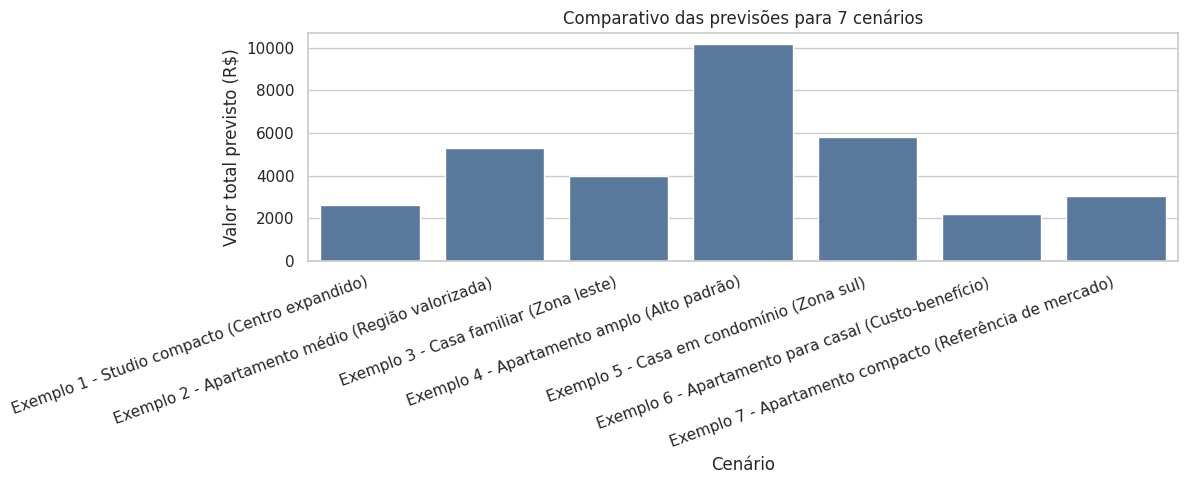

In [6]:
# Exemplos de cenários para apresentação
exemplos_apresentacao = pd.DataFrame([
    {
        "cenario": "Exemplo 1 - Studio compacto (Centro expandido)",
        "district": "Bela Vista",
        "tipo": "Studio e kitnet",
        "area": 25,
        "bedrooms": 1,
        "garage": 0,
    },
    {
        "cenario": "Exemplo 2 - Apartamento médio (Região valorizada)",
        "district": "Pinheiros",
        "tipo": "Apartamento",
        "area": 55,
        "bedrooms": 2,
        "garage": 1,
    },
    {
        "cenario": "Exemplo 3 - Casa familiar (Zona leste)",
        "district": "Tatuapé",
        "tipo": "Casa",
        "area": 95,
        "bedrooms": 3,
        "garage": 2,
    },
    {
        "cenario": "Exemplo 4 - Apartamento amplo (Alto padrão)",
        "district": "Vila Olímpia",
        "tipo": "Apartamento",
        "area": 110,
        "bedrooms": 3,
        "garage": 2,
    },
    {
        "cenario": "Exemplo 5 - Casa em condomínio (Zona sul)",
        "district": "Vila Andrade",
        "tipo": "Casa em condomínio",
        "area": 140,
        "bedrooms": 3,
        "garage": 2,
    },
    {
        "cenario": "Exemplo 6 - Apartamento para casal (Custo-benefício)",
        "district": "Mooca",
        "tipo": "Apartamento",
        "area": 40,
        "bedrooms": 1,
        "garage": 1,
    },
    {
        "cenario": "Exemplo 7 - Apartamento compacto (Referência de mercado)",
        "district": "Bela Vista",
        "tipo": "Apartamento",
        "area": 25,
        "bedrooms": 1,
        "garage": 0,
    },
])

exemplos_apresentacao["previsao_total"] = exemplos_apresentacao.apply(
    lambda r: prever_valor_total(
        district=r["district"],
        tipo=r["tipo"],
        area=r["area"],
        bedrooms=r["bedrooms"],
        garage=r["garage"],
    ),
    axis=1,
)

# Formata o valor monetário no padrão brasileiro para apresentação
exemplos_apresentacao["previsao_total_R$"] = exemplos_apresentacao["previsao_total"].map(
    lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

resultado_apresentacao = exemplos_apresentacao[
    ["cenario", "district", "tipo", "area", "bedrooms", "garage", "previsao_total_R$"]
]

display(resultado_apresentacao)

qtd_cenarios = len(exemplos_apresentacao)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=exemplos_apresentacao,
    x="cenario",
    y="previsao_total",
    color="#4C78A8",
)
plt.xticks(rotation=20, ha="right")
plt.title(f"Comparativo das previsões para {qtd_cenarios} cenários")
plt.ylabel("Valor total previsto (R$)")
plt.xlabel("Cenário")
plt.tight_layout()
plt.show()